# 📈 ARIMA Stock Price Forecasting

This notebook walks through a complete **ARIMA-based stock price forecasting pipeline**, from raw data to evaluation and future projections.

## What is ARIMA?

**ARIMA** stands for **AutoRegressive Integrated Moving Average**. It is a classical statistical model for time series forecasting, parameterised as **ARIMA(p, d, q)**:

| Parameter | Name | Meaning |
|-----------|------|---------|
| `p` | AutoRegressive order | Number of lagged past values used as predictors |
| `d` | Integration order | Number of times the series is differenced to make it stationary |
| `q` | Moving Average order | Number of lagged forecast errors used in the model |

## Pipeline Overview

```
Data  →  Stationarity Test  →  Auto ARIMA (grid search)  →  Rolling Forecast  →  Future Projection  →  Visualisation
```

> **Note:** `yfinance` requires internet access. If running locally, swap the synthetic data cell for the `yfinance` fetch block shown in the comments.

## 1. Imports & Setup

We need the following libraries:
- **`yfinance`** — download real stock data (requires internet)
- **`statsmodels`** — ARIMA model, ADF test, ACF/PACF plots
- **`sklearn`** — evaluation metrics (MAE, RMSE)
- **`matplotlib`** — visualisation
- **`pandas / numpy`** — data manipulation

Install if needed:
```bash
pip install yfinance statsmodels scikit-learn matplotlib pandas numpy
```

In [2]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Configuration

All key parameters are defined here so they are easy to tweak without hunting through the code.

| Variable | Default | Description |
|----------|---------|-------------|
| `TICKER` | `AAPL` | Stock ticker symbol |
| `PERIOD` | `2y` | How much historical data to fetch |
| `TEST_DAYS` | `30` | Days held out for out-of-sample evaluation |
| `FORECAST_DAYS` | `15` | Days to project into the future |
| `ARIMA_ORDER` | `None` | `None` triggers automatic grid search; or set manually e.g. `(1,1,1)` |

**Chart colour palette** is also defined here — dark background with teal/amber/red accents.

In [3]:
# ── Model & data parameters ────────────────────────────────────────────────────
TICKER        = "AAPL"   # Change to any valid ticker, e.g. "TSLA", "MSFT"
PERIOD        = "2y"     # yfinance period string: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
TEST_DAYS     = 30       # Number of trailing days reserved for evaluation
FORECAST_DAYS = 15       # Number of future business days to forecast
ARIMA_ORDER   = None     # None = auto grid-search; or supply tuple e.g. (1, 1, 1)

# ── Chart colour palette ───────────────────────────────────────────────────────
BG    = "#0d0f14"
PANEL = "#13161e"
ACCENT = "#00d4aa"
WARN  = "#f5a623"
RED   = "#e05c5c"
WHITE = "#e8eaf0"
GRAY  = "#3a3f52"

plt.rcParams.update({
    "figure.facecolor": BG,    "axes.facecolor": PANEL,
    "axes.edgecolor": GRAY,    "axes.labelcolor": WHITE,
    "xtick.color": WHITE,      "ytick.color": WHITE,
    "text.color": WHITE,       "grid.color": GRAY,
    "grid.alpha": 0.4,         "font.family": "monospace",
})

print("Configuration set.")

Configuration set.


## 3. Load Price Data

### Option A — Real data via `yfinance` *(requires internet)*
Uncomment the block below to fetch live OHLCV data from Yahoo Finance.

### Option B — Synthetic data via Geometric Brownian Motion *(used here)*
**Geometric Brownian Motion (GBM)** is the standard mathematical model for stock prices:

$$S_t = S_0 \cdot e^{\sum (\mu + \sigma \cdot Z_t)}$$

where:
- $\mu$ is the daily drift (expected return)
- $\sigma$ is the daily volatility
- $Z_t \sim \mathcal{N}(0,1)$ are standard normal shocks

A simulated bear-market dip is injected around day 200–240 to test regime robustness.

In [4]:
# ── Option A: Real data (uncomment if you have internet access) ────────────────
# raw    = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=False)
# prices = raw["Close"].dropna().squeeze()
# prices.index = pd.to_datetime(prices.index)

# ── Option B: Synthetic GBM data ──────────────────────────────────────────────
np.random.seed(42)
n_days   = 504      # approx. 2 trading years (252 days/yr)
mu_daily = 0.0004   # ~10% annual drift
sigma    = 0.015    # ~24% annual volatility
start_px = 182.0    # starting price in USD

shocks          = np.random.normal(mu_daily, sigma, n_days)
shocks[200:240] -= 0.004   # inject a bear-market dip
log_ret         = np.cumsum(shocks)
px_arr          = start_px * np.exp(log_ret)

idx    = pd.bdate_range(end="2024-12-31", periods=n_days)   # business days only
prices = pd.Series(px_arr, index=idx, name="Close")

print(f"Loaded {len(prices)} trading days: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Price range: ${prices.min():.2f} – ${prices.max():.2f}")
prices.tail()

Loaded 504 trading days: 2023-01-26 → 2024-12-31
Price range: $154.95 – $232.79


2024-12-25    199.395771
2024-12-26    202.266131
2024-12-27    208.226319
2024-12-30    203.985119
2024-12-31    205.797275
Freq: B, Name: Close, dtype: float64

## 4. Stationarity Test — Augmented Dickey-Fuller (ADF)

ARIMA requires the time series to be **stationary** (constant mean and variance over time). Raw stock prices are almost never stationary — they trend upward or downward.

The **ADF test** checks the null hypothesis:
> *H₀: The series has a unit root (non-stationary)*

- If **p-value > 0.05** → fail to reject H₀ → series is **non-stationary** → set `d = 1` (difference once)
- If **p-value ≤ 0.05** → reject H₀ → series is **stationary** → set `d = 0`

**First differencing** transforms prices into daily returns: $\Delta P_t = P_t - P_{t-1}$, which removes the trend and is typically stationary.

In [5]:
adf_raw  = adfuller(prices)
diff1    = prices.diff().dropna()       # first difference
adf_diff = adfuller(diff1)

d_order = 0 if adf_raw[1] < 0.05 else 1

print("=" * 45)
print(f"  ADF Statistic (raw series) : {adf_raw[0]:.4f}")
print(f"  p-value       (raw series) : {adf_raw[1]:.4f}  →  {'STATIONARY' if adf_raw[1] < 0.05 else 'NON-STATIONARY'}")
print()
print(f"  ADF Statistic (differenced): {adf_diff[0]:.4f}")
print(f"  p-value       (differenced): {adf_diff[1]:.4f}  →  {'STATIONARY' if adf_diff[1] < 0.05 else 'NON-STATIONARY'}")
print("=" * 45)
print(f"  Chosen d = {d_order}")

  ADF Statistic (raw series) : -1.4303
  p-value       (raw series) : 0.5677  →  NON-STATIONARY

  ADF Statistic (differenced): -22.2003
  p-value       (differenced): 0.0000  →  STATIONARY
  Chosen d = 1


## 5. Train / Test Split

We hold out the last `TEST_DAYS` trading days as an **out-of-sample test set**. The model never sees these prices during fitting — they are used purely for evaluation.

```
├──────────────── TRAIN (474 days) ────────────────┤── TEST (30 days) ──┤
```

This simulates real-world usage where you train on historical data and test on the most recent period.

In [6]:
train = prices.iloc[:-TEST_DAYS]
test  = prices.iloc[-TEST_DAYS:]

print(f"Training set : {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test set     : {len(test)}  days  ({test.index[0].date()}  → {test.index[-1].date()})")

Training set : 474 days  (2023-01-26 → 2024-11-19)
Test set     : 30  days  (2024-11-20  → 2024-12-31)


## 6. Automatic ARIMA Order Selection (AIC Grid Search)

If `ARIMA_ORDER` is `None`, we search over all combinations of `p ∈ {0,1,2,3}` and `q ∈ {0,1,2,3}` and select the model with the lowest **AIC (Akaike Information Criterion)**.

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

where $k$ is the number of parameters and $\hat{L}$ is the likelihood. AIC penalises complexity — a lower AIC means a better balance between fit quality and model simplicity.

> **Tip:** For faster results, skip grid search by setting `ARIMA_ORDER = (1, 1, 1)` in the config cell.

In [7]:
if ARIMA_ORDER is None:
    print("Grid-searching ARIMA(p, d, q) — this may take ~30 seconds...")
    best_aic, best_order = np.inf, (1, d_order, 1)

    for p, q in itertools.product(range(4), range(4)):
        try:
            m = ARIMA(train, order=(p, d_order, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d_order, q)
        except Exception:
            pass   # skip unconverged models

    ARIMA_ORDER = best_order
    print(f"\n✔ Best order : ARIMA{ARIMA_ORDER}")
    print(f"  Best AIC   : {best_aic:.2f}")
else:
    print(f"Using manually specified order: ARIMA{ARIMA_ORDER}")

Grid-searching ARIMA(p, d, q) — this may take ~30 seconds...


C:\Users\LENOVO\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



✔ Best order : ARIMA(0, 1, 0)
  Best AIC   : 2266.72


C:\Users\LENOVO\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 7. Rolling One-Step-Ahead Forecast (Test Set Evaluation)

Rather than fitting once and projecting 30 steps ahead (which compounds error), we use a **rolling forecast**:

```
For each day in the test set:
  1. Fit ARIMA on all data seen so far
  2. Predict the next single day
  3. Reveal the actual value and append it to history
  4. Repeat
```

This is the most realistic evaluation methodology — it mirrors how you would actually deploy the model day-by-day.

### Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error in dollars |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors more heavily |
| **MAPE** | $\frac{100}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|$ | Percentage error — scale-independent |

In [8]:
print("Running rolling one-step-ahead forecast...")

history    = list(train)
test_preds = []

for i, val in enumerate(test):
    m    = ARIMA(history, order=ARIMA_ORDER).fit()
    yhat = float(np.atleast_1d(m.forecast(steps=1))[0])
    test_preds.append(yhat)
    history.append(val)    # reveal actual value and add to history
    if (i + 1) % 10 == 0:
        print(f"  Step {i+1}/{TEST_DAYS} done")

test_preds = pd.Series(test_preds, index=test.index)

# ── Compute metrics ────────────────────────────────────────────────────────────
mae  = mean_absolute_error(test, test_preds)
rmse = np.sqrt(mean_squared_error(test, test_preds))
mape = (np.abs((test.values - test_preds.values) / test.values) * 100).mean()

print("\n" + "=" * 35)
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 35)

Running rolling one-step-ahead forecast...
  Step 10/30 done
  Step 20/30 done
  Step 30/30 done

  MAE  : $2.95
  RMSE : $3.58
  MAPE : 1.45%


## 8. Future Forecast

Now we refit the model on the **full dataset** (train + test) and project `FORECAST_DAYS` business days into the future.

`get_forecast()` returns both the point forecast and a **confidence interval**. We use a 90% CI (`alpha=0.10`), meaning the model expects the actual price to fall within the shaded band 90% of the time.

> ⚠️ The confidence interval **widens over time** — uncertainty compounds with each additional step, reflecting the inherent unpredictability of markets.

In [9]:
print("Fitting final model on full dataset and projecting forward...")

final_model = ARIMA(prices, order=ARIMA_ORDER).fit()
fc_res      = final_model.get_forecast(steps=FORECAST_DAYS)
fc_mean     = fc_res.predicted_mean
fc_ci       = fc_res.conf_int(alpha=0.10)   # 90% confidence interval

# Assign future business-day dates as the index
future_idx    = pd.bdate_range(prices.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)
fc_mean.index = future_idx
fc_ci.index   = future_idx

print(f"  Last known price : ${float(prices.iloc[-1]):.2f}  ({prices.index[-1].date()})")
print(f"  Forecast end     : ${float(fc_mean.iloc[-1]):.2f}  ({future_idx[-1].date()})")
print(f"  90% CI at end    : [${float(fc_ci.iloc[-1, 0]):.2f}, ${float(fc_ci.iloc[-1, 1]):.2f}]")

Fitting final model on full dataset and projecting forward...
  Last known price : $205.80  (2024-12-31)
  Forecast end     : $205.80  (2025-01-21)
  90% CI at end    : [$188.50, $223.10]


## 9. Visualisation

Six panels are arranged in a 3×3 grid:

| Panel | Content |
|-------|---------|
| **A (top, full width)** | Price history, rolling test forecast, future projection + CI |
| **B (mid-left)** | Residual bar chart — green = under-predicted, red = over-predicted |
| **C (mid-right)** | Model summary card (metrics + config) |
| **D (bottom-left)** | ACF of differenced series — informs `q` |
| **E (bottom-centre)** | PACF of differenced series — informs `p` |
| **F (bottom-right)** | Actual vs Predicted scatter — perfect fit lies on the diagonal |

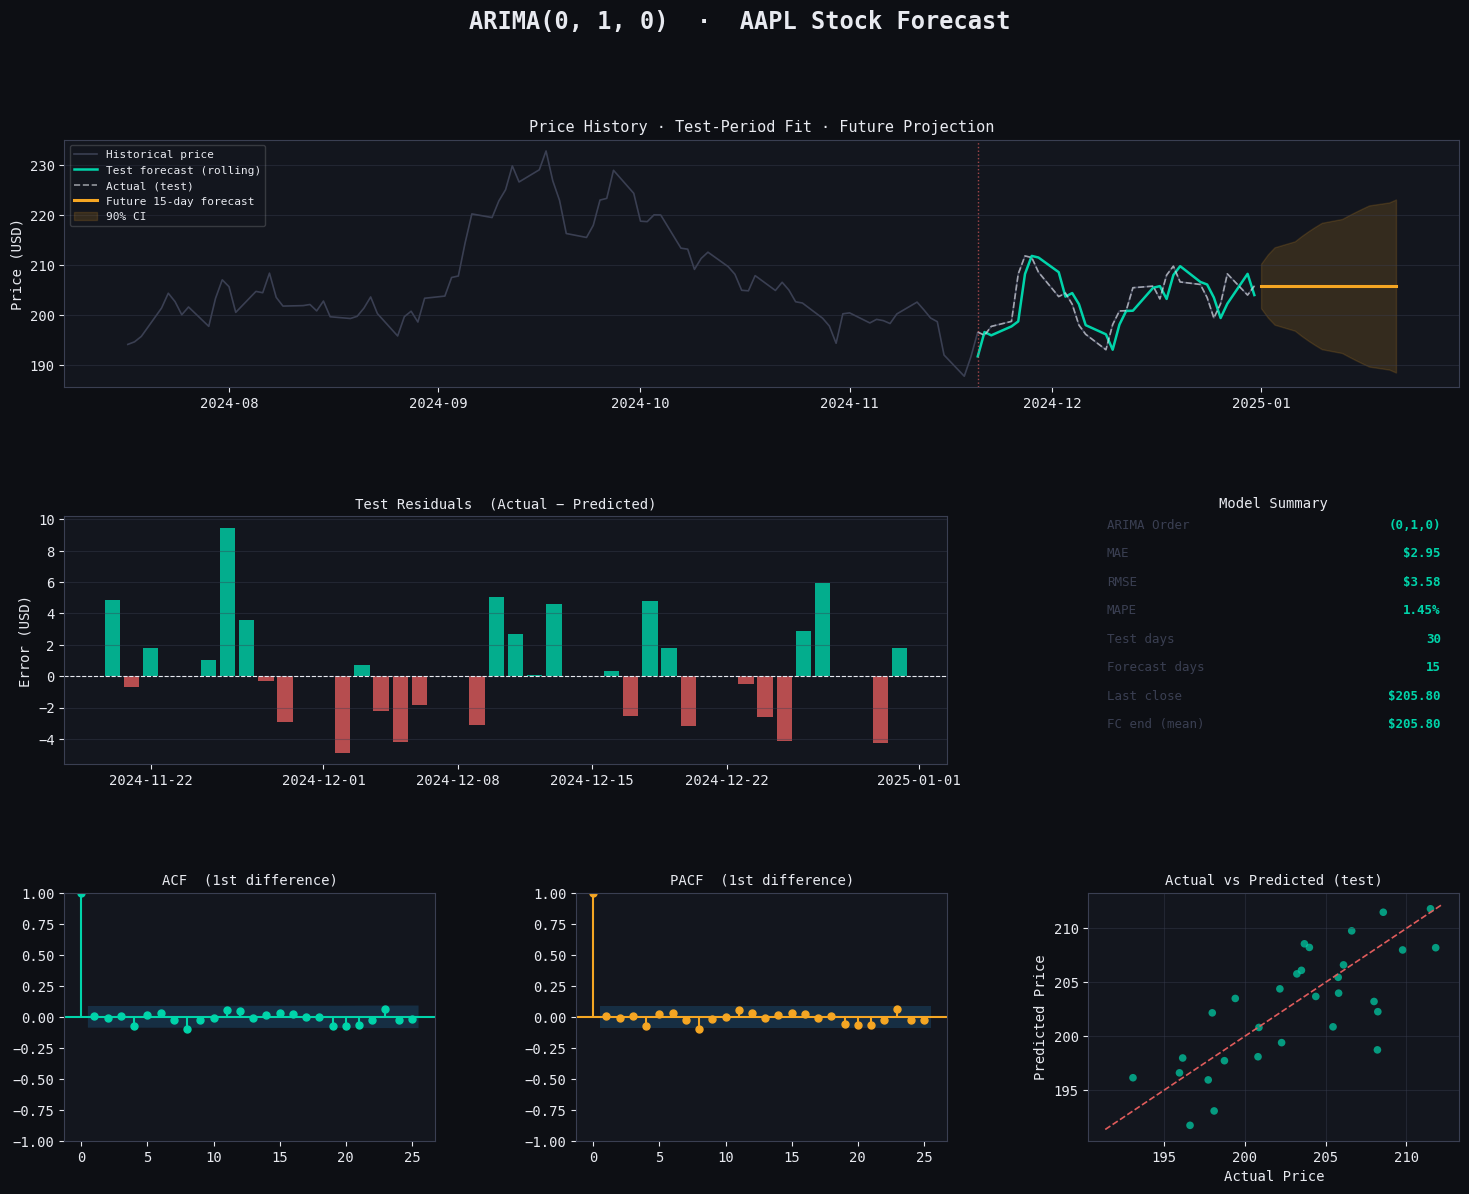

In [10]:
fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle(f"ARIMA{ARIMA_ORDER}  ·  {TICKER} Stock Forecast",
             fontsize=17, fontweight="bold", color=WHITE, y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── Panel A: Full history + test fit + future forecast ────────────────────────
ax1 = fig.add_subplot(gs[0, :])
LOOK_BACK = 120   # show last 120 days of history
ax1.plot(prices.iloc[-LOOK_BACK:], color=GRAY,  lw=1.2, label="Historical price")
ax1.plot(test_preds,               color=ACCENT, lw=1.8, label="Test forecast (rolling)")
ax1.plot(test,                     color=WHITE,  lw=1.2, alpha=0.6, linestyle="--", label="Actual (test)")
ax1.plot(fc_mean,                  color=WARN,   lw=2.2, label=f"Future {FORECAST_DAYS}-day forecast")
ax1.fill_between(future_idx, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color=WARN, alpha=0.15, label="90% CI")
ax1.axvline(test.index[0], color=RED, lw=1, linestyle=":", alpha=0.7)
ax1.set_title("Price History · Test-Period Fit · Future Projection", color=WHITE, fontsize=11)
ax1.legend(fontsize=8, loc="upper left", framealpha=0.2)
ax1.set_ylabel("Price (USD)")
ax1.grid(True, axis="y")

# ── Panel B: Residuals ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
residuals = test.values - test_preds.values
ax2.bar(test.index, residuals,
        color=[ACCENT if r >= 0 else RED for r in residuals], alpha=0.8, width=0.8)
ax2.axhline(0, color=WHITE, lw=0.8, linestyle="--")
ax2.set_title("Test Residuals  (Actual − Predicted)", color=WHITE, fontsize=10)
ax2.set_ylabel("Error (USD)")
ax2.grid(True, axis="y")

# ── Panel C: Metrics card ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.axis("off")
metrics = [
    ("ARIMA Order",   f"({ARIMA_ORDER[0]},{ARIMA_ORDER[1]},{ARIMA_ORDER[2]})"),
    ("MAE",           f"${mae:.2f}"),
    ("RMSE",          f"${rmse:.2f}"),
    ("MAPE",          f"{mape:.2f}%"),
    ("Test days",     str(TEST_DAYS)),
    ("Forecast days", str(FORECAST_DAYS)),
    ("Last close",    f"${float(prices.iloc[-1]):.2f}"),
    ("FC end (mean)", f"${float(fc_mean.iloc[-1]):.2f}"),
]
y0 = 0.95
for label, val in metrics:
    ax3.text(0.05, y0, label, color=GRAY,   fontsize=9, transform=ax3.transAxes)
    ax3.text(0.95, y0, val,   color=ACCENT, fontsize=9,
             transform=ax3.transAxes, ha="right", fontweight="bold")
    y0 -= 0.115
ax3.set_title("Model Summary", color=WHITE, fontsize=10)

# ── Panel D: ACF ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
plot_acf(diff1, lags=25, ax=ax4, color=ACCENT, vlines_kwargs={"colors": ACCENT})
ax4.set_title("ACF  (1st difference)", color=WHITE, fontsize=10)

# ── Panel E: PACF ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
plot_pacf(diff1, lags=25, ax=ax5, color=WARN, vlines_kwargs={"colors": WARN})
ax5.set_title("PACF  (1st difference)", color=WHITE, fontsize=10)

# ── Panel F: Actual vs Predicted scatter ─────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
lo = min(test.min(), test_preds.min()) * 0.998
hi = max(test.max(), test_preds.max()) * 1.002
ax6.scatter(test.values, test_preds.values, color=ACCENT, alpha=0.7, s=30, edgecolors="none")
ax6.plot([lo, hi], [lo, hi], color=RED, lw=1.2, linestyle="--")
ax6.set_xlabel("Actual Price")
ax6.set_ylabel("Predicted Price")
ax6.set_title("Actual vs Predicted (test)", color=WHITE, fontsize=10)
ax6.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("arima_stock_forecast.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
#print("Chart saved as arima_stock_forecast.png")

## 10. Model Diagnostics — ACF & PACF Interpretation

After fitting, it's good practice to check the model diagnostics more closely.

### How to Read ACF and PACF

| Plot | What it shows | Used to determine |
|------|--------------|-------------------|
| **ACF** | Correlation of the series with its own lags (direct + indirect) | `q` — MA order: how many lags cut off sharply |
| **PACF** | Correlation *after* removing intermediate lag effects | `p` — AR order: how many lags cut off sharply |

Spikes outside the blue confidence band indicate significant autocorrelation at that lag. Ideally, **residuals from the fitted model should show no significant autocorrelation** (white noise), confirming a good fit.

In [ ]:
# ── Residual diagnostics on the final model ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)

model_residuals = final_model.resid

plot_acf(model_residuals,  lags=25, ax=axes[0],
         color=ACCENT, vlines_kwargs={"colors": ACCENT})
axes[0].set_title("ACF of Model Residuals", color=WHITE)

plot_pacf(model_residuals, lags=25, ax=axes[1],
          color=WARN, vlines_kwargs={"colors": WARN})
axes[1].set_title("PACF of Model Residuals", color=WHITE)

for ax in axes:
    ax.set_facecolor(PANEL)

plt.suptitle("Residual Diagnostics — ideally no significant spikes outside the band",
             color=WHITE, fontsize=10)
plt.tight_layout()
plt.show()

## 11. Summary & Limitations

### What we built
- ✅ Automated stationarity testing with ADF
- ✅ Grid-search order selection using AIC
- ✅ Realistic rolling one-step-ahead evaluation
- ✅ Future projection with 90% confidence intervals
- ✅ Full diagnostic visualisation

### Known limitations of ARIMA for stocks

| Limitation | Why it matters |
|------------|----------------|
| **Linearity assumption** | Markets exhibit nonlinear dynamics ARIMA cannot capture |
| **Price-only input** | Ignores volume, sentiment, macro indicators, earnings |
| **Short horizon only** | Forecast quality degrades quickly beyond 5–10 days |
| **No volatility clustering** | ARCH/GARCH models handle heteroskedasticity better |
| **Market efficiency** | If prices already reflect all known info, patterns are minimal |

### Potential next steps
- **SARIMAX** — add exogenous features (e.g. interest rates, VIX)
- **GARCH** — model volatility instead of price levels
- **LSTM / Transformer** — deep learning for nonlinear patterns
- **Prophet** — robust trend + seasonality decomposition
- **Ensemble** — combine multiple models for better robustness